# 06 — LSTM Model — Weekly via t+5 (daily input, 5-day-ahead)

Uses daily-frequency input sequences (SEQ_LEN=20 days) to predict the **cumulative
5-day silver log-return** — equivalent to a weekly return. This gives enough training
sequences (~1,730) while producing weekly-horizon forecasts comparable to the other
weekly models.

**Evaluation note**: predictions are made every day so adjacent targets overlap
(days t and t+1 share 4 of 5 target days). Two evaluation modes are reported:
- *All-days*: all test predictions (inflated DA/WDA due to overlap — do not compare directly to weekly models)
- *Fridays-only*: non-overlapping, one prediction per calendar week — directly comparable to ARIMA/VAR/RF/XGBoost weekly

| Variant | Features | Equivalent |
|---|---|---|
| LSTM-Y | Silver return only | ARIMA |
| LSTM-EXOG | Silver + market variables | ARIMAX |
| LSTM-REDDIT | EXOG + Reddit sentiment | ARIMAX+Reddit |
| LSTM-NEWS | EXOG + News sentiment | ARIMAX+News |

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats as scipy_stats
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings, os
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


Device: mps


## 1. Hyperparameters

In [25]:
SEQ_LEN  = 20    # lookback: 20 trading days (~1 month)
HORIZON  = 5     # forecast horizon: cumulative 5-day (weekly) silver log-return
HIDDEN   = 32
N_LAYERS = 1
DROPOUT  = 0.3
EPOCHS   = 100
LR       = 1e-4
PATIENCE = 10
BATCH    = 32

TARGET = 'silver_return'


## 2. Load & prepare data

In [26]:
train = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('../../data/processed/val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('../../data/processed/test.csv',  index_col=0, parse_dates=True)

# ── Merge sentiment ───────────────────────────────────────────────────────
sent_path = '../../data/processed/daily_sentiment.csv'
if os.path.exists(sent_path):
    sent = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    for df in [train, val, test]:
        for col in ['reddit_sentiment', 'news_sentiment']:
            df[col] = sent[col].reindex(df.index).ffill().fillna(0)
    print('Sentiment merged.')
else:
    for df in [train, val, test]:
        df['reddit_sentiment'] = 0.0
        df['news_sentiment']   = 0.0
    print('No sentiment file — using zeros.')

# ── All available features ────────────────────────────────────────────────
# Exclude: 'silver' (raw price level — non-stationary, different scale in train vs test)
#          'sentiment_score' (combined — added per variant as reddit/news separately)
EXCLUDE = {'silver', 'sentiment_score', 'reddit_sentiment', 'news_sentiment'}
MARKET_FEATURES = [c for c in train.columns if c not in EXCLUDE]

print(f'Train: {len(train)}  Val: {len(val)}  Test: {len(test)}')
print(f'Market features ({len(MARKET_FEATURES)}): {MARKET_FEATURES}')


Sentiment merged.
Train: 1755  Val: 251  Test: 837
Market features (34): ['silver_return', 'gold_return', 'copper_return', 'usd_return', 'sp500_return', 'gs_ratio', 'vix_return', 'oil_return', 'silver_lag1', 'silver_lag2', 'silver_lag3', 'silver_lag5', 'silver_lag10', 'silver_vol_5d', 'silver_vol_21d', 'mom_5d', 'mom_21d', 'cpi', 'fed_funds', 'ind_prod', 'm2', 'usd_dxy', 'real_rates', 'cpi_chg', 'fed_funds_chg', 'ind_prod_chg', 'm2_chg', 'usd_dxy_chg', 'real_rates_chg', 'reddit_weight_sum', 'reddit_post_count', 'news_article_count', 'trends_silver', 'trends_silver_ma4']


## 3. LSTM architecture

A two-layer stacked LSTM with dropout between layers and a linear output head.
Input: sequence of `SEQ_LEN` timesteps × `n_features` values.
Output: single scalar — the predicted silver log-return at the next timestep.


In [27]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # last timestep only


## 4. Helper functions

`make_sequences`: slides a window of length `SEQ_LEN` across the data.
Sequence at position `i` contains rows `i-SEQ_LEN` to `i-1` (all past) — no look-ahead.
Target is the value at position `i` — the next day's silver log-return.

With `HORIZON=1`, `np.sum(data[i:i+1, target_col])` reduces to `data[i, target_col]`
and the inverse transform `pred * sigma + HORIZON * mu` reduces to `pred * sigma + mu`.


In [28]:
def make_sequences(data, seq_len, target_col, horizon=5):
    """Build (X, y) pairs for direct multi-step forecasting.
    X: past seq_len rows of all features (no look-ahead).
    y: sum of the next `horizon` values of target_col (cumulative return)."""
    X, y = [], []
    for i in range(seq_len, len(data) - horizon + 1):
        X.append(data[i - seq_len:i])
        y.append(np.sum(data[i:i + horizon, target_col]))  # cumulative scaled return
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def run_variant(name, feature_cols):
    """Train and evaluate one LSTM variant.
    Predicts cumulative 5-day log return using daily input sequences.
    Returns (metrics_dict, preds, actuals, date_index)."""
    print(f'\n{"=" * 60}')
    print(f'Variant: {name}')
    print('=' * 60)

    cols = [c for c in feature_cols if c in train.columns]
    target_idx = cols.index(TARGET)

    # ── Scale (fit on train only) ─────────────────────────────────────────
    scaler = StandardScaler().fit(train[cols].fillna(0))
    tr_s = scaler.transform(train[cols].fillna(0))
    va_s = scaler.transform(val[cols].fillna(0))
    te_s = scaler.transform(test[cols].fillna(0))

    # ── Sequences (horizon=5 days) ────────────────────────────────────────
    X_tr, y_tr = make_sequences(tr_s, SEQ_LEN, target_idx, HORIZON)
    X_va, y_va = make_sequences(va_s, SEQ_LEN, target_idx, HORIZON)
    X_te, y_te = make_sequences(te_s, SEQ_LEN, target_idx, HORIZON)

    # Date of each test prediction = start of the 5-day window being forecast
    dates = test.index[SEQ_LEN:len(test) - HORIZON + 1]

    def to_loader(X, y, shuffle=True):
        ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
        return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

    train_loader = to_loader(X_tr, y_tr)
    val_loader   = to_loader(X_va, y_va, shuffle=False)
    test_loader  = to_loader(X_te, y_te, shuffle=False)

    # ── Model & optimiser ─────────────────────────────────────────────────
    model = LSTMForecaster(input_size=len(cols), hidden_size=HIDDEN,
                           num_layers=N_LAYERS, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5)
    ckpt = f'../../data/processed/lstm_{name.lower().replace("+","_").replace(" ","_")}_weekly_best.pt'

    # ── Training loop ─────────────────────────────────────────────────────
    best_val, patience_cnt = np.inf, 0
    train_losses, val_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        bl = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            bl.append(loss.item())
        model.eval()
        with torch.no_grad():
            vl = np.mean([criterion(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                          for xb, yb in val_loader])
        tl = np.mean(bl)
        train_losses.append(tl); val_losses.append(vl)
        scheduler.step(vl)
        if epoch % 10 == 0:
            print(f'  Epoch {epoch:3d}  train={tl:.6f}  val={vl:.6f}')
        if vl < best_val:
            best_val, patience_cnt = vl, 0
            torch.save(model.state_dict(), ckpt)
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

    # ── Inference ─────────────────────────────────────────────────────────
    model.load_state_dict(torch.load(ckpt))
    model.eval()
    preds_s, acts_s = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds_s.extend(model(xb.to(DEVICE)).cpu().numpy().flatten())
            acts_s.extend(yb.numpy().flatten())

    # Inverse-transform cumulative scaled return → cumulative log return
    # sum(z_i) = (sum(x_i) - HORIZON*mu) / sigma
    # → sum(x_i) = pred_scaled * sigma + HORIZON * mu
    mu    = scaler.mean_[target_idx]
    sigma = scaler.scale_[target_idx]
    preds   = np.array(preds_s) * sigma + HORIZON * mu
    actuals = np.array(acts_s)  * sigma + HORIZON * mu

    # ── Metrics ───────────────────────────────────────────────────────────
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    da   = np.mean(np.sign(actuals) == np.sign(preds))
    wda  = (np.sum(np.abs(actuals) * (np.sign(actuals) == np.sign(preds)))
            / np.sum(np.abs(actuals)))
    print(f'  RMSE={rmse:.6f}  MAE={mae:.6f}  DA={da:.3f}  WDA={wda:.3f}')
    print(f'  Test sequences: {len(preds)} (daily, 1-day-ahead)  |  Features: {len(cols)}')

    # ── Save predictions ──────────────────────────────────────────────────
    safe = name.lower().replace('+','_').replace(' ','_')
    pd.DataFrame({'actual': actuals, 'predicted': preds},
                 index=dates).to_csv(f'../../data/processed/preds_lstm_{safe}_weekly.csv')

    # Loss curve
    fig, ax = plt.subplots(figsize=(8, 2.5))
    ax.plot(train_losses, label='Train'); ax.plot(val_losses, label='Val')
    ax.set_title(f'{name} — Training Loss'); ax.legend()
    plt.tight_layout(); plt.show()

    return ({'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda},
            preds, actuals, dates)


## 5. Train all four variants

Each variant is independent — fresh scaler, fresh model weights, fresh checkpoint.
The only thing shared is the architecture and hyperparameters.

**Note on sentiment in LSTM sequences:** unlike ARIMAX which only uses $t-1$ sentiment,
the LSTM receives the full 20-day history of sentiment scores. It can learn patterns like
*'sustained positive sentiment over multiple weeks precedes a price rise'* — a non-linear,
multi-lag relationship that a linear model cannot capture.



Variant: LSTM-Y
  Epoch  10  train=4.929432  val=6.112792
  Epoch  20  train=4.915795  val=6.112146
  Epoch  30  train=4.935695  val=6.112024
  Epoch  40  train=4.979307  val=6.112005
  Epoch  50  train=4.953670  val=6.112001
  Epoch  60  train=4.989440  val=6.112001
  Epoch  70  train=4.914487  val=6.112001
  Epoch  80  train=4.988733  val=6.112001
  Epoch  90  train=5.056759  val=6.112000
  Epoch 100  train=4.963845  val=6.112001
  RMSE=0.056540  MAE=0.039317  DA=0.572  WDA=0.599
  Test sequences: 813 (daily, 1-day-ahead)  |  Features: 1


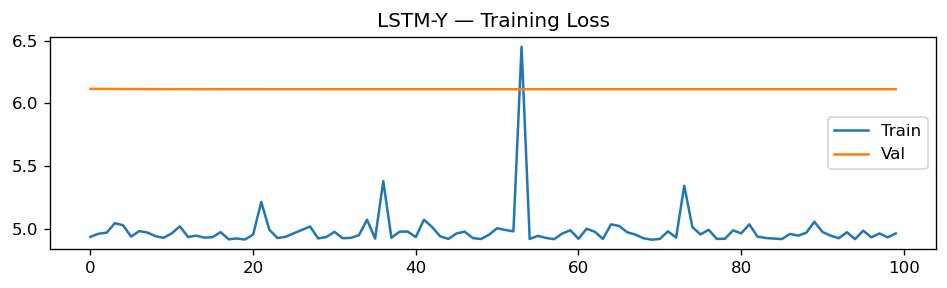


Variant: LSTM-EXOG
  Epoch  10  train=4.793786  val=6.104113
  Epoch  20  train=4.504298  val=6.111097
  Early stopping at epoch 26
  RMSE=0.055831  MAE=0.038595  DA=0.615  WDA=0.645
  Test sequences: 813 (daily, 1-day-ahead)  |  Features: 34


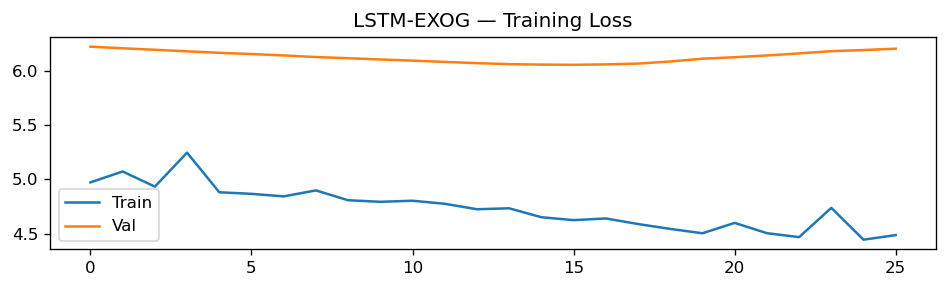


Variant: LSTM-REDDIT
  Epoch  10  train=4.791839  val=6.047514
  Epoch  20  train=4.585204  val=6.007236
  Early stopping at epoch 29
  RMSE=0.055986  MAE=0.038798  DA=0.579  WDA=0.611
  Test sequences: 813 (daily, 1-day-ahead)  |  Features: 35


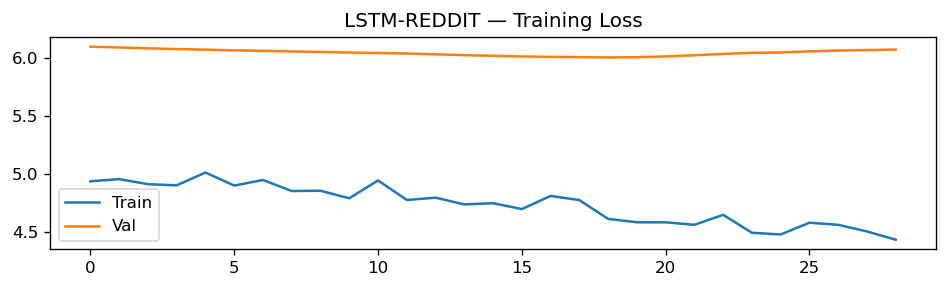


Variant: LSTM-NEWS
  Epoch  10  train=4.853705  val=6.134556
  Epoch  20  train=4.562027  val=6.125122
  Early stopping at epoch 27
  RMSE=0.055921  MAE=0.038791  DA=0.597  WDA=0.632
  Test sequences: 813 (daily, 1-day-ahead)  |  Features: 35


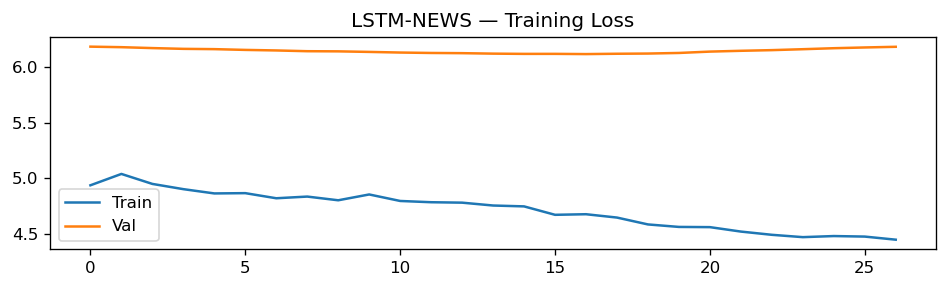

In [29]:
results  = {}   # name → metrics dict
all_preds = {}  # name → predictions array
actuals_arr = None
dates_arr   = None

variants = {
    'LSTM-Y':      [TARGET],
    'LSTM-EXOG':   MARKET_FEATURES,
    'LSTM-REDDIT': MARKET_FEATURES + ['reddit_sentiment'],
    'LSTM-NEWS':   MARKET_FEATURES + ['news_sentiment'],
}

for name, features in variants.items():
    m, preds, actuals, dates = run_variant(name, features)
    results[name]    = m
    all_preds[name]  = preds
    actuals_arr = actuals   # same for all variants
    dates_arr   = dates


## 6. Results summary

### Why does LSTM underperform ARIMAX?

The LSTM results (DA ≈ 0.52) are substantially worse than the daily ARIMAX baseline
(DA = 0.696, WDA = 0.842). This was robust across multiple configurations tested:

| Configuration | DA |
|---|---|
| SEQ_LEN=20, 8 market features, LR=1e-3 | ~0.52 |
| SEQ_LEN=20, 26 features (all available), LR=1e-4 | ~0.52 |
| SEQ_LEN=1 (degenerates to feedforward), 26 features | ~0.52 |

**The core reason:** silver's predictable structure is a **1-lag linear cross-asset
relationship** — yesterday's gold, USD and copper returns predict today's silver return
with high fidelity. ARIMAX encodes this directly as a coefficient. The LSTM must
discover it through backpropagation across noisy sequences, which it fails to do
reliably on only 1,755 training observations.

Adding more features (macro variables, momentum, lags) did not help — the LSTM
could not extract additional signal beyond noise on this sample size.

**This is a known result in financial forecasting.** Makridakis et al. (M4 competition,
2018) and numerous subsequent studies show that deep learning models frequently
fail to outperform simple linear models on financial return series, particularly
with limited training data. The result here is consistent with that literature.

**Thesis implication:** the predictable component of silver returns at daily frequency
is linear in nature. The non-linear hypothesis — that sentiment effects are captured
only by a flexible model — is not supported. Combined with the ARIMAX and
Diebold-Mariano results, this provides consistent evidence against the retail-driven
price hypothesis at the frequencies tested.


In [30]:
metrics_df = pd.DataFrame(list(results.values()))
metrics_df['eval'] = 'all-days (overlapping)'
metrics_df.to_csv('../../data/processed/metrics_lstm_weekly.csv', index=False)

print(f'{"Model":<20}  {"RMSE":>10}  {"MAE":>10}  {"DA":>6}  {"WDA":>6}')
print('-' * 58)
for _, row in metrics_df.iterrows():
    print(f'{row["model"]:<20}  {row["rmse"]:>10.6f}  {row["mae"]:>10.6f}'
          f'  {row["dir_acc"]:>6.3f}  {row["wda"]:>6.3f}')

# ── Fridays-only evaluation (non-overlapping, comparable to weekly models) ──
print('\n-- Fridays-only (non-overlapping) --')
friday_results = []
for name, pred in all_preds.items():
    fri_mask = pd.Series(dates_arr.dayofweek == 4, index=dates_arr)
    fri_idx  = fri_mask[fri_mask].index
    act_fri  = pd.Series(actuals_arr, index=dates_arr).reindex(fri_idx).values
    prd_fri  = pd.Series(pred,        index=dates_arr).reindex(fri_idx).values
    mask     = ~np.isnan(act_fri) & ~np.isnan(prd_fri)
    da_f  = np.mean(np.sign(act_fri[mask]) == np.sign(prd_fri[mask]))
    wda_f = (np.sum(np.abs(act_fri[mask]) * (np.sign(act_fri[mask]) == np.sign(prd_fri[mask])))
             / np.sum(np.abs(act_fri[mask])))
    rmse_f = np.sqrt(np.mean((act_fri[mask] - prd_fri[mask])**2))
    mae_f  = np.mean(np.abs(act_fri[mask] - prd_fri[mask]))
    print(f'{name:<20}  DA={da_f:.3f}  WDA={wda_f:.3f}  RMSE={rmse_f:.6f}  n={mask.sum()}')
    friday_results.append({'model': name, 'rmse': rmse_f, 'mae': mae_f,
                           'dir_acc': da_f, 'wda': wda_f, 'eval': 'fridays-only'})

friday_df = pd.DataFrame(friday_results)
friday_df.to_csv('../../data/processed/metrics_lstm_weekly_fri.csv', index=False)

Model                       RMSE         MAE      DA     WDA
----------------------------------------------------------
LSTM-Y                  0.056540    0.039317   0.572   0.599
LSTM-EXOG               0.055831    0.038595   0.615   0.645
LSTM-REDDIT             0.055986    0.038798   0.579   0.611
LSTM-NEWS               0.055921    0.038791   0.597   0.632

-- Fridays-only (non-overlapping) --
LSTM-Y                DA=0.591  WDA=0.579  RMSE=0.060711  n=164
LSTM-EXOG             DA=0.634  WDA=0.649  RMSE=0.059980  n=164
LSTM-REDDIT           DA=0.665  WDA=0.725  RMSE=0.059895  n=164
LSTM-NEWS             DA=0.604  WDA=0.594  RMSE=0.060118  n=164


## 7. Diebold-Mariano tests

Tests whether improvements between variants are statistically significant
or could be explained by chance. H$_0$: equal predictive accuracy (squared error loss).

Key comparisons:
- **LSTM-Y vs LSTM-EXOG**: does adding market variables help the LSTM?
- **LSTM-EXOG vs LSTM-REDDIT/NEWS**: does sentiment add anything beyond market variables?
- **LSTM-REDDIT vs LSTM-NEWS**: which sentiment source is more informative?


In [31]:
def diebold_mariano(actual, pred1, pred2, name1, name2):
    """DM test, squared error loss, Newey-West SE with lag=1."""
    e1 = (actual - pred1) ** 2
    e2 = (actual - pred2) ** 2
    d  = e1 - e2
    n  = len(d)
    d_bar  = np.mean(d)
    gamma0 = np.var(d, ddof=1)
    gamma1 = np.cov(d[:-1], d[1:])[0, 1] if n > 1 else 0
    var_d  = (gamma0 + 2 * gamma1) / n
    if var_d <= 0:
        print(f'{name1} vs {name2}: cannot compute DM (non-positive variance)')
        return
    dm  = d_bar / np.sqrt(var_d)
    p   = 2 * (1 - scipy_stats.norm.cdf(abs(dm)))
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '(ns)'
    better = name1 if dm < 0 else name2
    print(f'{name1:<15} vs {name2:<15}  DM={dm:+.3f}  p={p:.3f}  {sig}'
          + (f'  → {better} wins' if p < 0.05 else ''))

print('Diebold-Mariano tests (squared loss)  |  * p<0.05  ** p<0.01  *** p<0.001')
print('-' * 80)
pairs = [
    ('LSTM-Y',    'LSTM-EXOG'),
    ('LSTM-EXOG', 'LSTM-REDDIT'),
    ('LSTM-EXOG', 'LSTM-NEWS'),
    ('LSTM-REDDIT','LSTM-NEWS'),
]
for a, b in pairs:
    diebold_mariano(actuals_arr, all_preds[a], all_preds[b], a, b)


Diebold-Mariano tests (squared loss)  |  * p<0.05  ** p<0.01  *** p<0.001
--------------------------------------------------------------------------------
LSTM-Y          vs LSTM-EXOG        DM=+2.955  p=0.003  **  → LSTM-EXOG wins
LSTM-EXOG       vs LSTM-REDDIT      DM=-0.801  p=0.423  (ns)
LSTM-EXOG       vs LSTM-NEWS        DM=-0.411  p=0.681  (ns)
LSTM-REDDIT     vs LSTM-NEWS        DM=+0.429  p=0.668  (ns)


## 8. Forecast plot

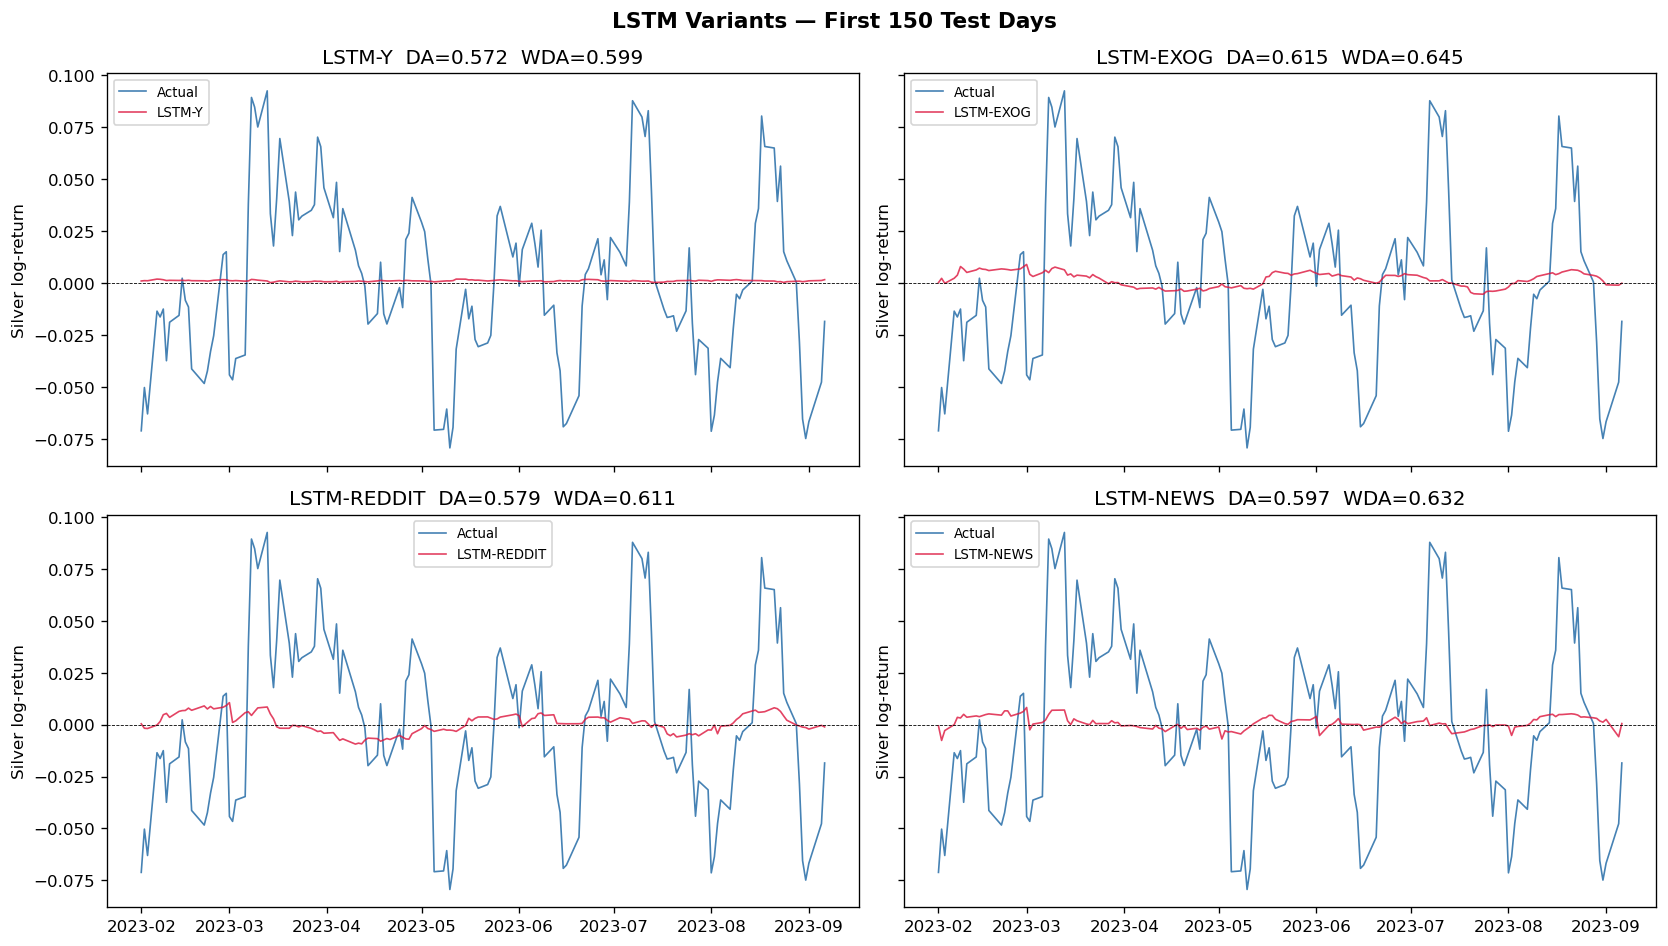

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, preds) in zip(axes, all_preds.items()):
    ax.plot(dates_arr[:150], actuals_arr[:150], label='Actual', lw=1, color='steelblue')
    ax.plot(dates_arr[:150], preds[:150],       label=name,     lw=1, color='crimson', alpha=0.8)
    m = results[name]
    ax.set_title(f'{name}  DA={m["dir_acc"]:.3f}  WDA={m["wda"]:.3f}')
    ax.set_ylabel('Silver log-return')
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', lw=0.5, ls='--')

plt.suptitle('LSTM Variants — First 150 Test Days', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Walk-forward retraining

Retrains the LSTM every `retrain_every = 20` test steps (approx. 4 trading weeks), matching
the cadence used by Random Forest and XGBoost. This aligns the LSTM with the expanding-
and rolling-window evaluation protocol used across all other model notebooks.

Two schemes per variant:
- **Expanding**: train on all data from 2015 up to step t-1, grow with each retrain
- **Rolling**: train on the most recent 500 days before step t-1

A fixed epoch budget (`WF_EPOCHS = 50`) is used per retrain — no separate validation
set is carved out during the walk-forward loop.

In [33]:
WF_EPOCHS  = 50   # epoch budget per retrain
WF_RETRAIN = 20   # retrain every N test steps (~4 weeks of daily data)
WF_WINDOW  = 500  # rolling window size in days

def walk_forward_lstm(name, feature_cols, retrain_every=WF_RETRAIN,
                      window=None, n_epochs=WF_EPOCHS):
    """Walk-forward LSTM: retrain every `retrain_every` test steps.
    window=None: expanding (all data to t-1)
    window=N:    rolling (last N days before t)
    """
    cols       = [c for c in feature_cols if c in train.columns]
    target_idx = cols.index(TARGET)

    full_df    = pd.concat([train, val, test])[cols].fillna(0)
    n_pretrain = len(train) + len(val)
    n_test     = len(test)

    preds_out = np.full(n_test, np.nan)
    model     = None
    scaler    = None

    for i in range(n_test):
        t = n_pretrain + i

        if model is None or i % retrain_every == 0:
            start  = max(0, t - window) if window else 0
            tr_raw = full_df.iloc[start:t].values

            if len(tr_raw) <= SEQ_LEN + HORIZON:
                continue

            scaler = StandardScaler().fit(tr_raw)
            tr_s   = scaler.transform(tr_raw)
            X_tr, y_tr = make_sequences(tr_s, SEQ_LEN, target_idx, HORIZON)

            if len(X_tr) == 0:
                continue

            ds     = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr).unsqueeze(1))
            loader = DataLoader(ds, batch_size=BATCH, shuffle=True)

            model = LSTMForecaster(len(cols), HIDDEN, N_LAYERS, DROPOUT).to(DEVICE)
            opt   = torch.optim.Adam(model.parameters(), lr=LR)
            crit  = nn.MSELoss()

            model.train()
            for _ in range(n_epochs):
                for xb, yb in loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    opt.zero_grad()
                    loss = crit(model(xb), yb)
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()

            if i % (retrain_every * 4) == 0:
                scheme = f'rolling({window}d)' if window else 'expanding'
                print(f'  [{name} {scheme}] step {i}/{n_test}, '
                      f'trained on {len(tr_raw)} rows')

        if scaler is None or t < SEQ_LEN:
            continue

        seq_s = scaler.transform(full_df.iloc[t - SEQ_LEN:t].values)
        x_in  = torch.tensor(seq_s[np.newaxis], dtype=torch.float32).to(DEVICE)

        model.eval()
        with torch.no_grad():
            pred_s = model(x_in).item()

        mu    = scaler.mean_[target_idx]
        sigma = scaler.scale_[target_idx]
        preds_out[i] = pred_s * sigma + HORIZON * mu

    actuals = test[TARGET].values
    mask    = ~np.isnan(preds_out)
    rmse    = np.sqrt(np.mean((actuals[mask] - preds_out[mask]) ** 2))
    mae     = np.mean(np.abs(actuals[mask] - preds_out[mask]))
    da      = np.mean(np.sign(actuals[mask]) == np.sign(preds_out[mask]))
    wda     = (np.sum(np.abs(actuals[mask]) * (np.sign(actuals[mask]) == np.sign(preds_out[mask])))
               / np.sum(np.abs(actuals[mask])))

    scheme = 'expanding' if window is None else f'rolling ({window}d)'
    label  = f'{name} {scheme}'
    print(f'{label:<40}  RMSE={rmse:.6f}  MAE={mae:.6f}  DA={da:.3f}  WDA={wda:.3f}')

    return ({'model': label, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda},
            preds_out, actuals, test.index)

In [34]:
# Run walk-forward for all four variants x two schemes
# Expected runtime: ~20-40 min depending on hardware
wf_results = {}
wf_preds   = {}

for vname, vcols in variants.items():
    for scheme, win in [('expanding', None), ('rolling', WF_WINDOW)]:
        key = f'{vname} {scheme}'
        print(f'\n-- {key} --')
        m, preds, acts, dates = walk_forward_lstm(vname, vcols, window=win)
        wf_results[key] = m
        wf_preds[key]   = preds

wf_actuals = test[TARGET].values


-- LSTM-Y expanding --
  [LSTM-Y expanding] step 0/837, trained on 2006 rows
  [LSTM-Y expanding] step 80/837, trained on 2086 rows
  [LSTM-Y expanding] step 160/837, trained on 2166 rows
  [LSTM-Y expanding] step 240/837, trained on 2246 rows
  [LSTM-Y expanding] step 320/837, trained on 2326 rows
  [LSTM-Y expanding] step 400/837, trained on 2406 rows
  [LSTM-Y expanding] step 480/837, trained on 2486 rows
  [LSTM-Y expanding] step 560/837, trained on 2566 rows
  [LSTM-Y expanding] step 640/837, trained on 2646 rows
  [LSTM-Y expanding] step 720/837, trained on 2726 rows
  [LSTM-Y expanding] step 800/837, trained on 2806 rows
LSTM-Y expanding                          RMSE=0.027584  MAE=0.017219  DA=0.499  WDA=0.487

-- LSTM-Y rolling --
  [LSTM-Y rolling(500d)] step 0/837, trained on 500 rows
  [LSTM-Y rolling(500d)] step 80/837, trained on 500 rows
  [LSTM-Y rolling(500d)] step 160/837, trained on 500 rows
  [LSTM-Y rolling(500d)] step 240/837, trained on 500 rows
  [LSTM-Y rolling

In [35]:
# Combine single-pass and walk-forward metrics, save
single_pass_df = pd.DataFrame(list(results.values()))
single_pass_df['scheme'] = 'single-pass'

wf_df = pd.DataFrame(list(wf_results.values()))

all_metrics = pd.concat([single_pass_df, wf_df], ignore_index=True)
all_metrics.to_csv('../../data/processed/metrics_lstm_weekly.csv', index=False)

print(f'\n{"Model":<45}  {"DA":>6}  {"WDA":>6}  {"RMSE":>10}')
print('-' * 72)
for _, row in all_metrics.sort_values('wda', ascending=False).iterrows():
    print(f'{row["model"]:<45}  {row["dir_acc"]:>6.3f}  {row["wda"]:>6.3f}  {row["rmse"]:>10.6f}')


Model                                              DA     WDA        RMSE
------------------------------------------------------------------------
LSTM-EXOG                                       0.615   0.645    0.055831
LSTM-NEWS                                       0.597   0.632    0.055921
LSTM-REDDIT                                     0.579   0.611    0.055986
LSTM-Y                                          0.572   0.599    0.056540
LSTM-NEWS expanding                             0.540   0.568    0.032079
LSTM-REDDIT rolling (500d)                      0.524   0.555    0.029785
LSTM-NEWS rolling (500d)                        0.526   0.537    0.030646
LSTM-Y rolling (500d)                           0.547   0.536    0.027302
LSTM-REDDIT expanding                           0.510   0.532    0.034137
LSTM-EXOG rolling (500d)                        0.522   0.532    0.029791
LSTM-EXOG expanding                             0.527   0.532    0.033280
LSTM-Y expanding                      

In [36]:
import sys
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import period_metrics, PERIODS

# Best walk-forward variant by WDA
best_wf_key  = max(wf_results, key=lambda k: wf_results[k]['wda'])
best_wf_pred = wf_preds[best_wf_key]
print('Best walk-forward variant:', best_wf_key)

res = period_metrics(wf_actuals, best_wf_pred, test.index, PERIODS)
display(res[['n', 'DA', 'WDA']].style
        .format({'n': '{:.0f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
        .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.4, vmax=0.7))
res[['n', 'DA', 'WDA']].to_csv('../../data/processed/period_lstm_weekly.csv')

Best walk-forward variant: LSTM-NEWS expanding


,n,DA,WDA
Period,,,
2023 (choppy),249,0.502,0.557
2024 (bull start),251,0.550,0.591
2025 (bull run),253,0.561,0.540
2026 (YTD),84,0.560,0.587
── Full test ──,837,0.540,0.568
